# Term Project

This project will explore the relationship between the availability of resources at various public schools in New York and metrics pertaining to AP exam performance. We want to know how well factors like passing rate and average scores can predict resource wealth. 

Our learning model is Logistic Regression, in addition to Feature Selection at the end to see what features end up being quantitatively the most important toward predicting the availability of resources at a public school. The features from the Feature Selection are then used in a Logistic Regression, and the metrics from this Logistic Regression are evaluated against previous regression metrics from student-selected features. 

Prior to the analysis, it was expected that passing rate and average scores would be extremely good predictors of resource availability. We thought this would be a good assumption because of the common association between schools' wealth and their academic performance. 

The model will be evaluated based on accuracy and confusion matrix metrics from sklearn. The model was expected to perform well because of the large amount of data available for fitting.

This database contains counts of AP and IB assessments by student subgroup and performance level, AP and IB course counts, and an AP and IB course researcher file by student subgroup. School district, statewide, county, and needs resource aggregations are included (From New York State Education Department).

In [20]:
import numpy as np
import pandas as pd


### Data Cleaning

In [21]:
df = pd.read_csv("AP_IB_Assessment2024.csv")

# select relevant columns
df = df[['aggregation_type', 'NRC_DESC',  'APIB_IND', 'SUBJECT_AREA', 'GRADE_LEVEL', 'tested_student_cnt', 'proficient_student_cnt',	
    'level1_cnt', 'level2_cnt',	'level3_cnt', 'level4_cnt',	'level5_cnt']]

# remove rows with no score information (represented as '-' in dataset)
df = df.replace(r'^\s*-\s*$', np.nan, regex=True)
df = df.dropna()
df


C:\Users\User\AppData\Local\Temp\ipykernel_9812\1593127268.py:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AP_IB_Assessment2024.csv")


,aggregation_type,NRC_DESC,APIB_IND,SUBJECT_AREA,GRADE_LEVEL,tested_student_cnt,proficient_student_cnt,level1_cnt,level2_cnt,level3_cnt,level4_cnt,level5_cnt
5705,Need/Resource Category,NEW YORK CITY,AP,Computer Sciences,10th Grade,111,34,59,18,17,7,10
5706,Need/Resource Category,NEW YORK CITY,AP,Computer Sciences,11th Grade,1221,881,252,88,159,226,496
5707,Need/Resource Category,NEW YORK CITY,AP,Computer Sciences,12th Grade,1004,417,468,119,165,133,119
5708,Need/Resource Category,NEW YORK CITY,AP,Computer Sciences,9th Grade,17,3,12,2,0,3,0
5710,Need/Resource Category,NEW YORK CITY,AP,Computer Sciences,10th Grade,2349,1865,200,284,690,693,482
...,...,...,...,...,...,...,...,...,...,...,...,...
467529,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0
467530,Public School,RURAL HIGH NEEDS,AP,Social Studies,11th Grade,35,26,2,7,20,6,0
467531,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,5,5,0,0,1,1,3
467533,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0


In [22]:
# cast types
# cast columns 0-4 to string
str_cols = ['aggregation_type', 'NRC_DESC', 'APIB_IND', 'SUBJECT_AREA', 'GRADE_LEVEL']
df[str_cols] = df[str_cols].astype(str)

# cast numeric count columns (6-11) to int
int_cols = ['proficient_student_cnt', 'level1_cnt', 'level2_cnt', 'level3_cnt', 'level4_cnt', 'level5_cnt']
df[int_cols] = df[int_cols].astype(int)


# filter for public school and AP exams only
df = df[(df['APIB_IND'] == 'AP') & (df['aggregation_type'] == 'Public School')]


df


,aggregation_type,NRC_DESC,APIB_IND,SUBJECT_AREA,GRADE_LEVEL,tested_student_cnt,proficient_student_cnt,level1_cnt,level2_cnt,level3_cnt,level4_cnt,level5_cnt
238761,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,10th Grade,10,4,1,5,2,1,1
238762,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,11th Grade,6,3,1,2,0,3,0
238763,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,12th Grade,6,4,0,2,1,2,1
238765,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,11th Grade,90,39,19,32,21,16,2
238767,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,12th Grade,18,15,0,3,8,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...
467529,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0
467530,Public School,RURAL HIGH NEEDS,AP,Social Studies,11th Grade,35,26,2,7,20,6,0
467531,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,5,5,0,0,1,1,3
467533,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0


In [23]:
# make column for passing rate
df['passing_rate'] = df['proficient_student_cnt']/df['tested_student_cnt']
# make column for average score
df['avg_score'] = (1/df['tested_student_cnt']) * (df['level1_cnt'] + 2 * df['level2_cnt'] + 3 * df['level3_cnt'] + 4 * df['level4_cnt'] + 5 * df['level5_cnt'])
df

C:\Users\User\AppData\Local\Temp\ipykernel_9812\4254054267.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['passing_rate'] = df['proficient_student_cnt']/df['tested_student_cnt']
C:\Users\User\AppData\Local\Temp\ipykernel_9812\4254054267.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_score'] = (1/df['tested_student_cnt']) * (df['level1_cnt'] + 2 * df['level2_cnt'] + 3 * df['level3_cnt'] + 4 * df['level4_cnt'] + 5 * df['level5_cnt'])


,aggregation_type,NRC_DESC,APIB_IND,SUBJECT_AREA,GRADE_LEVEL,tested_student_cnt,proficient_student_cnt,level1_cnt,level2_cnt,level3_cnt,level4_cnt,level5_cnt,passing_rate,avg_score
238761,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,10th Grade,10,4,1,5,2,1,1,0.400000,2.600000
238762,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,11th Grade,6,3,1,2,0,3,0,0.500000,2.833333
238763,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,12th Grade,6,4,0,2,1,2,1,0.666667,3.333333
238765,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,11th Grade,90,39,19,32,21,16,2,0.433333,2.444444
238767,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,12th Grade,18,15,0,3,8,3,4,0.833333,3.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467529,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0,0.545455,2.363636
467530,Public School,RURAL HIGH NEEDS,AP,Social Studies,11th Grade,35,26,2,7,20,6,0,0.742857,2.857143
467531,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,5,5,0,0,1,1,3,1.000000,4.400000
467533,Public School,RURAL HIGH NEEDS,AP,Mathematics,12th Grade,11,6,2,3,6,0,0,0.545455,2.363636


In [24]:
# create is_resource_constrained from classifying NRC column
# 0 is resource-constrained, 1 is resource-rich
# classifications derived from dataset README
df['target'] = df['NRC_DESC'].copy()

resourceClass = {'AVERAGE NEEDS' : 1, 
                 'CHARTER SCHOOL' : 1, 
                 'LARGE CITY' : 0,
                 'LOW NEEDS' : 1,
                 'RURAL HIGH NEEDS': 0,
                 'URBAN/SUBURBAN/HIGH NEEDS' : 0,
                 'NEW YORK CITY' : 0}

df = df.replace({'target' : resourceClass})

# change grade levels to integer counterparts using same method (assume 'Not HS' is 8th grade)
gradeClass = {
    'Not HS' : 8,
    '9th Grade' : 9,
    '10th Grade' : 10,
    '11th Grade' : 11,
    '12th Grade' : 12
}

df = df.replace({"GRADE_LEVEL" : gradeClass})
df

C:\Users\User\AppData\Local\Temp\ipykernel_9812\3191296945.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['NRC_DESC'].copy()
C:\Users\User\AppData\Local\Temp\ipykernel_9812\3191296945.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'target' : resourceClass})
C:\Users\User\AppData\Local\Temp\ipykernel_9812\3191296945.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `resul

,aggregation_type,NRC_DESC,APIB_IND,SUBJECT_AREA,GRADE_LEVEL,tested_student_cnt,proficient_student_cnt,level1_cnt,level2_cnt,level3_cnt,level4_cnt,level5_cnt,passing_rate,avg_score,target
238761,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,10,10,4,1,5,2,1,1,0.400000,2.600000,0
238762,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,11,6,3,1,2,0,3,0,0.500000,2.833333,0
238763,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,Computer Sciences,12,6,4,0,2,1,2,1,0.666667,3.333333,0
238765,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,11,90,39,19,32,21,16,2,0.433333,2.444444,0
238767,Public School,URBAN/SUBURBAN/HIGH NEEDS,AP,ELA,12,18,15,0,3,8,3,4,0.833333,3.444444,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467529,Public School,RURAL HIGH NEEDS,AP,Mathematics,12,11,6,2,3,6,0,0,0.545455,2.363636,0
467530,Public School,RURAL HIGH NEEDS,AP,Social Studies,11,35,26,2,7,20,6,0,0.742857,2.857143,0
467531,Public School,RURAL HIGH NEEDS,AP,Mathematics,12,5,5,0,0,1,1,3,1.000000,4.400000,0
467533,Public School,RURAL HIGH NEEDS,AP,Mathematics,12,11,6,2,3,6,0,0,0.545455,2.363636,0


### Data Visualization

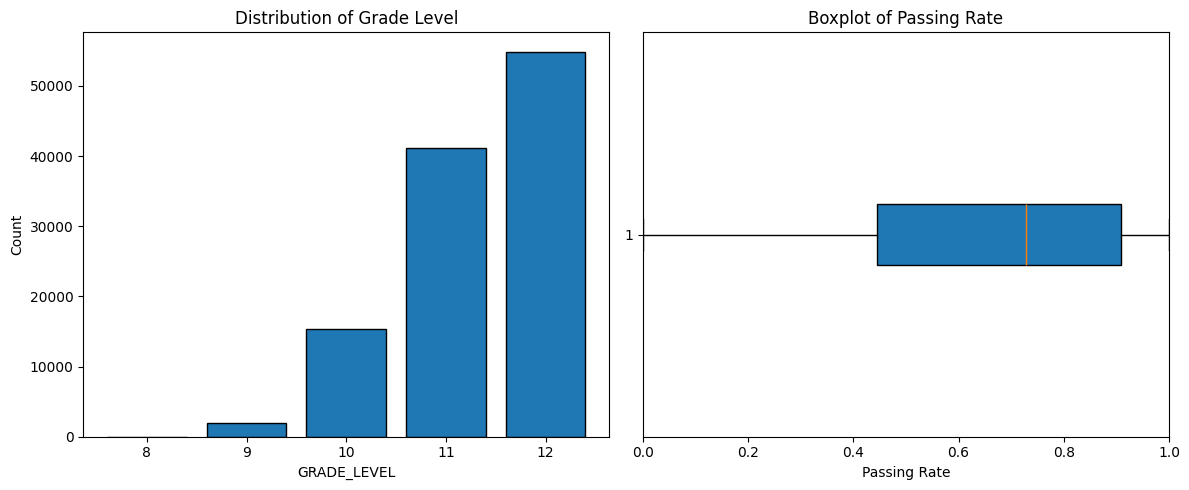

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Histogram for GRADE_LEVEL
plt.subplot(1,2,1)
bins = [7.5,8.5,9.5,10.5,11.5,12.5]
plt.hist(df['GRADE_LEVEL'], bins=bins, edgecolor='black', rwidth=0.8)
plt.xticks([8,9,10,11,12])
plt.xlabel('GRADE_LEVEL')
plt.ylabel('Count')
plt.title('Distribution of Grade Level')

# Boxplot for passing_rate
plt.subplot(1,2,2)
passing = df['passing_rate']
plt.boxplot(passing, vert=False, patch_artist=True)
plt.xlabel('Passing Rate')
plt.title('Boxplot of Passing Rate')
plt.xlim(0,1)
plt.tight_layout()
plt.show()



In [35]:
cols = ['GRADE_LEVEL', 'tested_student_cnt', 'passing_rate', 'avg_score']
stats = df[cols].agg(['mean', 'median', 'min', 'max']).round(2).T
print(stats)

                     mean  median  min     max
GRADE_LEVEL         11.31   11.00  8.0    12.0
tested_student_cnt  24.59   14.00  5.0  1430.0
passing_rate         0.65    0.73  0.0     1.0
avg_score            3.06    3.16  1.0     5.0


### Model

Model Accuracy (using .score):  0.7254624928252903


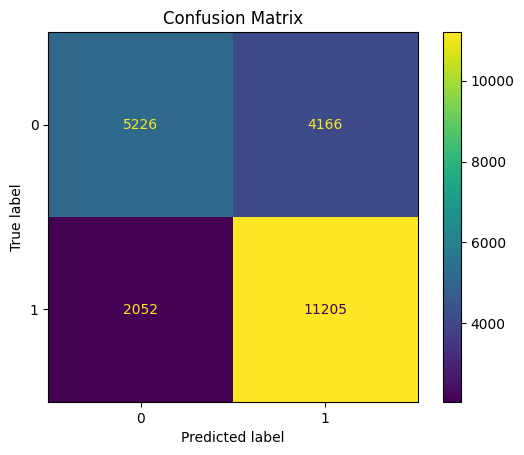

              precision    recall  f1-score   support

           0       0.72      0.56      0.63      9392
           1       0.73      0.85      0.78     13257

    accuracy                           0.73     22649
   macro avg       0.72      0.70      0.70     22649
weighted avg       0.72      0.73      0.72     22649



In [6]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# choosing grade level, passing rate, and average score as predictors
X = df[['GRADE_LEVEL', 'passing_rate', 'avg_score']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=23)


model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy (using .score): ", accuracy)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred=model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(y_test, y_pred))

The model accuracy is lower than expected, and has a tendency to predict more false positives, meaning this model is more likely to predict that a school is resource-rich when it's resource-constrained. This points to AP exam performance in resource-constrained schools in the training dataset being better than expected-- this aligns with the idea that even resource-constrained schools have students that perform as well as students from resource-rich schools. 

### Improving the model -- removing grade level

Model Accuracy (using .score):  0.7207382224380767


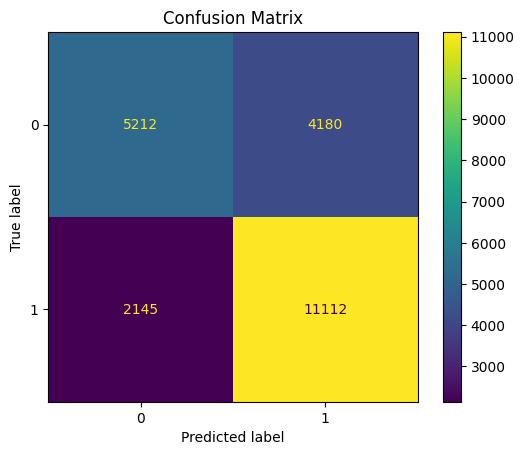

              precision    recall  f1-score   support

           0       0.71      0.55      0.62      9392
           1       0.73      0.84      0.78     13257

    accuracy                           0.72     22649
   macro avg       0.72      0.70      0.70     22649
weighted avg       0.72      0.72      0.71     22649



In [7]:
# fit model without grade level this time

X = df[['passing_rate', 'avg_score']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=23)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy (using .score): ", accuracy)

y_pred=model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(y_test, y_pred))


The model accuracy decreased slightly when grade level was not included as an input feature-- this may be because grade level is an important feature, but we learn later from Feature Selection that that is likely not the case. The change could be attributed to the specific random state split of the training and testing dataset instead of the importance of the feature itself. 

### Improving the model -- Grade Level and Average Score

Model Accuracy (using .score):  0.7292595699589386


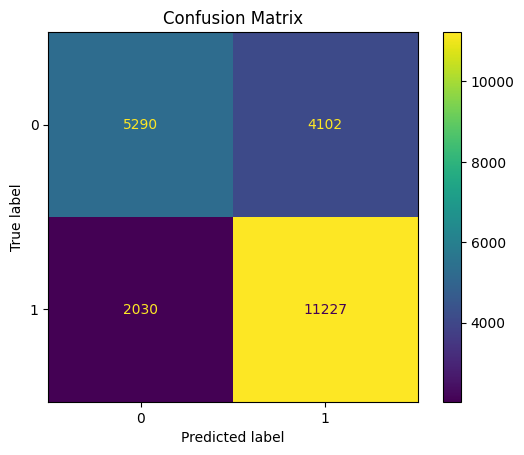

              precision    recall  f1-score   support

           0       0.72      0.56      0.63      9392
           1       0.73      0.85      0.79     13257

    accuracy                           0.73     22649
   macro avg       0.73      0.71      0.71     22649
weighted avg       0.73      0.73      0.72     22649



In [8]:
# fit model with different parameters

X = df[['GRADE_LEVEL', 'avg_score']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=23)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy (using .score): ", accuracy)

y_pred=model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(y_test, y_pred))

The model performance slightly increased when passing rate was not included as an input feature. Again, this is more likely because of random state selection than any importance of passing rate as a feature, especially because it had a low importance score from Feature Selection. 

### Improving the model -- using Feature Selection

In [9]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

# make a new df with numerical categories for subject_area to see if model selects it
dfN = df.copy()
subjectClass = {
    'Computer Sciences' : 1,
    'ELA' : 2,
    'Fine and Performing Arts' : 3,
    'Global Studies' : 4,
    'Mathematics' : 5,
    'Other' : 6, 
    'Science' : 7,
    'Second Languages' : 8,
    'Social Studies' : 9
}
dfN = dfN.replace({"SUBJECT_AREA" : subjectClass})

# include all columns (except target) in input features
X = dfN.iloc[:, 3:14]
feature_names = X.columns
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = dfN['target']

# use SelectFromModel with base estimator Logistic Regression to select features
model = SelectFromModel(estimator=LogisticRegression()).fit(X, y)
X_new = model.transform(X)
selected_features = feature_names[model.get_support()]
print(selected_features)

# get importance score of each feature
importance_scores = abs(model.estimator_.coef_[0])
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
print("\nFeature importance scores:")
print(feature_importance.sort_values('Importance', ascending=False))

C:\Users\User\AppData\Local\Temp\ipykernel_9812\2417125382.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfN = dfN.replace({"SUBJECT_AREA" : subjectClass})


Index(['level1_cnt', 'level4_cnt', 'level5_cnt', 'avg_score'], dtype='object')

Feature importance scores:
                   Feature  Importance
10               avg_score    0.892368
8               level5_cnt    0.544009
7               level4_cnt    0.312886
4               level1_cnt    0.274198
1              GRADE_LEVEL    0.191881
9             passing_rate    0.161715
0             SUBJECT_AREA    0.093911
6               level3_cnt    0.074971
2       tested_student_cnt    0.062015
5               level2_cnt    0.037343
3   proficient_student_cnt    0.030316


Feature Selection revealed that avg_score is actually the most important predictor of resource availability. Contrary to our initial selections, the count of students who scored 1s, 4s, and 5s were more important features than grade level and passing rate. This makes sense when considering the nature of AP scores-- they're graded on a curve, meaning that scores reflect the performance of students relative to each other, not just the exam material itself. This aspect is likely what makes those features good predictors of resource availablity.

Model Accuracy (using .score):  0.7239171707360148


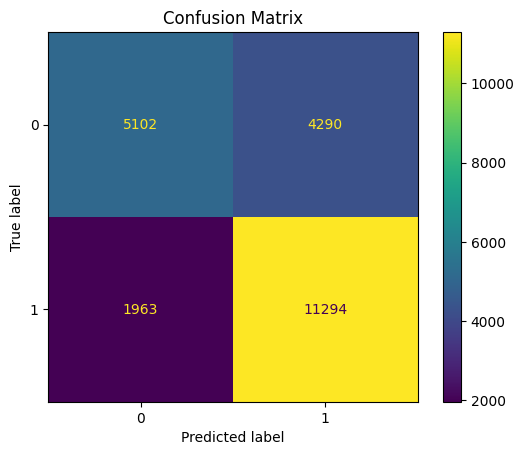

              precision    recall  f1-score   support

           0       0.72      0.54      0.62      9392
           1       0.72      0.85      0.78     13257

    accuracy                           0.72     22649
   macro avg       0.72      0.70      0.70     22649
weighted avg       0.72      0.72      0.72     22649



In [10]:
# fit model using selected features

X = df[['level1_cnt', 'level4_cnt', 'level5_cnt', 'avg_score']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=23)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy (using .score): ", accuracy)

y_pred=model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(y_test, y_pred))

Surprisingly, with the model-chosen features, the Logistic Regression model did not perform any better than the previous ones. Something interesting to note was that this model was even more likely to predict false positives than the first one, likely for the same reason-- students at resource-constrained schools still have the ability to perform as well as their counterparts at resource-rich schools. The inclusion of score data put an emphasis on these high-scorers from resource-constrained schools, which is probably why the model predicted more false positives.

## Improving Results

As previously stated, many of the differences in model performance could be attributed to noise from the random state selection. We could improve the model using cross-validation methods to suppress the effect of this noise. We could also calculate a new feature as a predictor-- for example, the original dataset had information about student demographics, which could be a powerful predictor.

In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

X = df[['level1_cnt', 'level4_cnt', 'level5_cnt', 'avg_score']]
y = df['target']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=23)
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)

kf = KFold(n_splits=100, random_state = 23, shuffle=True)

cvScores=[]
i = 1
for train_index, test_index in kf.split(Xtrain):
    print(f"Fold: {i} ==================================================================")
    X_train, X_validation = Xtrain[train_index], Xtrain[test_index]
    y_train, y_validation = y.iloc[train_index], y.iloc[test_index]
    
    print(len(X_train))
    print(len(X_validation))
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    ypred = model.predict(X_validation)
    acc = 100*accuracy_score(y_validation, ypred)
    print('Accuracy %.2f %%'%acc)
    cvScores.append(acc)
    i += 1






Fold: 1 ==================================================================
89688
906
Accuracy 51.88 %
Fold: 2 ==================================================================
89688
906
Accuracy 49.34 %
Fold: 3 ==================================================================
89688
906
Accuracy 50.22 %
Fold: 4 ==================================================================
89688
906
Accuracy 50.44 %
Fold: 5 ==================================================================
89688
906
Accuracy 48.57 %
Fold: 6 ==================================================================
89688
906
Accuracy 50.66 %
Fold: 7 ==================================================================
89688
906
Accuracy 52.87 %
Fold: 8 ==================================================================
89688
906
Accuracy 49.89 %
Fold: 9 ==================================================================
89688
906
Accuracy 49.67 %
Fold: 10 ==================================================================
89688


## References

[New York State Education Department](https://data.nysed.gov/downloads.php)